<a href="https://colab.research.google.com/github/dilekmirac/goruntu_isleme/blob/main/hafta2_g%C3%B6rev3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import torch

print(f"OpenCV Versiyonu: {cv2.__version__}")
print(f"CUDA Kullanılabilir mi (PyTorch/GPU): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Aktif GPU Modeli: {torch.cuda.get_device_name(0)}")

OpenCV Versiyonu: 5.0.0
CUDA Kullanılabilir mi (PyTorch/GPU): True
Aktif GPU Modeli: Tesla T4


           ZAMAN ÖLÇÜM RAPORU
Tek Çekirdek (Sıralı) Süre : 0.1017 saniye
4 Çekirdek (Paralel) Süre  : 0.1723 saniye
Hızlanma Oranı (Speedup)   : 0.59 kat daha hızlı


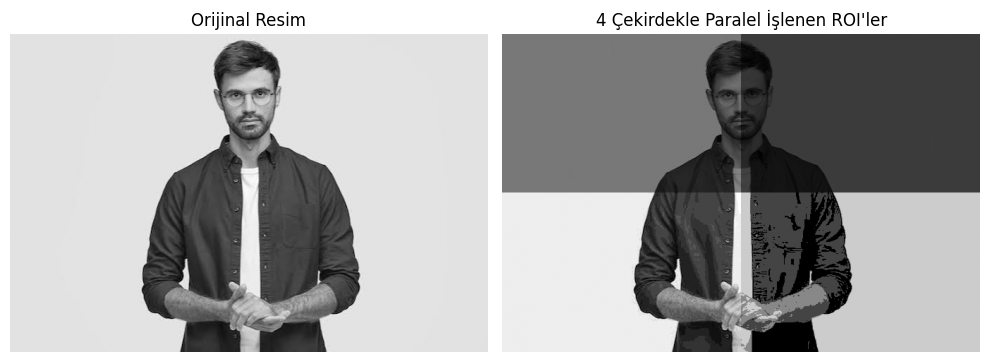

In [ ]:
import cv2
import numpy as np
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Çekirdeklerin çalıştıracağı ROI işleme fonksiyonu
# -------------------------------------------------------------------------
def roi_isle(veri):
    roi, bolum_no = veri
    h, w = roi.shape
    islenmis_roi = np.zeros((h, w), dtype=np.uint8)

    # Satır - Sütun piksellerini gezme
    for i in range(h):
        for j in range(w):
            p = int(roi[i, j])

            if bolum_no == 1:
                islenmis_roi[i, j] = p // 2          # Parlaklık yarıya
            elif bolum_no == 2:
                islenmis_roi[i, j] = p // 4          # Parlaklık çeyreğe
            elif bolum_no == 3:
                islenmis_roi[i, j] = (p // 16) * 16  # 4-bit (16 seviye)
            else:
                islenmis_roi[i, j] = (p // 64) * 64  # 2-bit (4 seviye)

    return islenmis_roi

# -------------------------------------------------------------------------
# 2. Ana Çalışma ve Süre Kıyaslama Bloğu
# -------------------------------------------------------------------------
if __name__ == '__main__':
    img_bgr = cv2.imread('insan.jpg')
    if img_bgr is None:
        raise FileNotFoundError("'insan.jpg' bulunamadı!")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    yukseklik, genislik = img_gray.shape

    # Resmi 4 eşit ROI parçasına böl
    orta_y = yukseklik // 2
    orta_x = genislik // 2

    roi1 = img_gray[0:orta_y, 0:orta_x]          # Sol-Üst
    roi2 = img_gray[0:orta_y, orta_x:genislik]   # Sağ-Üst
    roi3 = img_gray[orta_y:yukseklik, 0:orta_x]  # Sol-Alt
    roi4 = img_gray[orta_y:yukseklik, orta_x:genislik] # Sağ-Alt

    gorevler = [(roi1, 1), (roi2, 2), (roi3, 3), (roi4, 4)]

    # ---------------------------------------------------------------------
    # DENEY 1: Tek Çekirdekle Sıralı İşleme (Sequential)
    # ---------------------------------------------------------------------
    baslangic_tek = time.perf_counter()
    sonuclar_tek = [roi_isle(g) for g in gorevler]
    bitis_tek = time.perf_counter()
    sure_tek = bitis_tek - baslangic_tek

    # ---------------------------------------------------------------------
    # DENEY 2: 4 Çekirdekle Paralel İşleme (Multiprocessing)
    # ---------------------------------------------------------------------
    baslangic_paralel = time.perf_counter()
    with Pool(processes=4) as pool:
        sonuclar_paralel = pool.map(roi_isle, gorevler)
    bitis_paralel = time.perf_counter()
    sure_paralel = bitis_paralel - baslangic_paralel

    # ---------------------------------------------------------------------
    # Süre Raporu Yazdırma
    # ---------------------------------------------------------------------
    hizlanma = sure_tek / sure_paralel if sure_paralel > 0 else 0
    print("=" * 45)
    print("           ZAMAN ÖLÇÜM RAPORU")
    print("=" * 45)
    print(f"Tek Çekirdek (Sıralı) Süre : {sure_tek:.4f} saniye")
    print(f"4 Çekirdek (Paralel) Süre  : {sure_paralel:.4f} saniye")
    print(f"Hızlanma Oranı (Speedup)   : {hizlanma:.2f} kat daha hızlı")
    print("=" * 45)

    # Görselleri birleştir ve göster
    ust = np.hstack((sonuclar_paralel[0], sonuclar_paralel[1]))
    alt = np.hstack((sonuclar_paralel[2], sonuclar_paralel[3]))
    nihai_resim = np.vstack((ust, alt))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Orijinal Resim")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(nihai_resim, cmap='gray')
    plt.title("4 Çekirdekle Paralel İşlenen ROI'ler")
    plt.axis('off')

    plt.tight_layout()
    plt.show()